# Ch 13 · Lab 4 — Stratified K-fold

원본: `07_Sonar-K-fold.py`

작은 데이터셋(208개)에서 단 한 번의 train/test 분할은 우연에 의존. **K번 다른 분할**로 학습/평가해서 평균을 보면 더 신뢰할 수 있음.

## 0. 환경

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Dense

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold

2026-05-12 17:02:58.786294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778572978.801832 1516776 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778572978.806763 1516776 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.14.1


## 1. 데이터

In [2]:
DATA = "../../data/sonar.csv"
df = pd.read_csv(DATA, header=None)
X = df.iloc[:, 0:60].to_numpy(dtype="float32")
y_str = df.iloc[:, 60].to_numpy()
y = LabelEncoder().fit_transform(y_str).astype("float32")
print("X:", X.shape, "y:", y.shape, "분포:", np.bincount(y.astype(int)))

X: (208, 60) y: (208,) 분포: [111  97]


## 2. K=10 fold 학습

In [3]:
def build_model():
    return Sequential([
        Input(shape=(60,)),
        Dense(24, activation="relu"),
        Dense(10, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

In [4]:
N_FOLDS = 10
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)

accuracies = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    keras.utils.set_random_seed(fold)  # 매 fold 다른 초기화
    model = build_model()
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["accuracy"])
    model.fit(X[train_idx], y[train_idx], epochs=100, batch_size=5, verbose=0)
    acc = model.evaluate(X[test_idx], y[test_idx], verbose=0)[1]
    accuracies.append(acc)
    print(f"fold {fold:2d}  test acc = {acc:.4f}")

accuracies = np.array(accuracies)
print(f"\n평균 = {accuracies.mean():.4f}")
print(f"표준편차 = {accuracies.std():.4f}")
print(f"최소/최대 = {accuracies.min():.4f} / {accuracies.max():.4f}")

2026-05-12 17:03:01.078003: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


fold  1  test acc = 0.7143
fold  2  test acc = 0.8571
fold  3  test acc = 0.8095
fold  4  test acc = 0.9524
fold  5  test acc = 0.8095
fold  6  test acc = 0.8095
fold  7  test acc = 0.7619
fold  8  test acc = 0.8571
fold  9  test acc = 0.9500
fold 10  test acc = 0.7500

평균 = 0.8271
표준편차 = 0.0751
최소/최대 = 0.7143 / 0.9524


## 3. fold별 정확도 분포

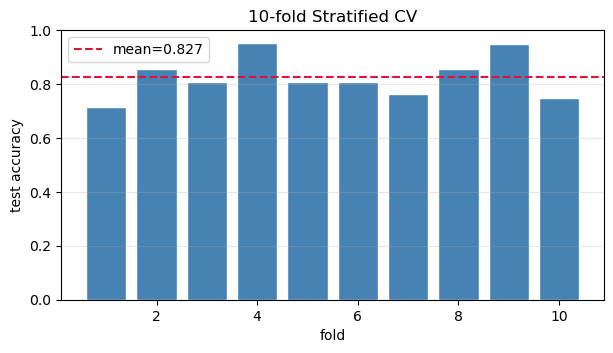

In [5]:
plt.figure(figsize=(7, 3.5))
plt.bar(range(1, N_FOLDS + 1), accuracies, color="steelblue", edgecolor="white")
plt.axhline(accuracies.mean(), color="crimson", ls="--", label=f"mean={accuracies.mean():.3f}")
plt.xlabel("fold"); plt.ylabel("test accuracy")
plt.title(f"{N_FOLDS}-fold Stratified CV")
plt.legend(); plt.grid(alpha=0.3, axis="y")
plt.show()

## 마무리 — 검증 전략 비교
| Lab | 평가 방법 | 신뢰도 |
| - | - | - |
| 1 | 학습 데이터로 평가 | ❌ |
| 2 | 70/30 단일 분할 | ⚠ (우연 영향) |
| 3 | 저장/로드 검증 | (배포 관점) |
| 4 | 10-fold CV | ✅ (분산까지 보임) |